In [20]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict  ,Literal

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage , HumanMessage
from dotenv import load_dotenv

from pydantic import BaseModel , Field
import os

In [21]:
load_dotenv()

True

In [22]:
llm = ChatGroq(
    model = 'llama-3.3-70b-versatile' , 
    api_key = os.getenv('GROQ_API_KEY')
)

In [23]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [24]:
structured_llm = llm.with_structured_output(TweetEvaluation)

In [25]:
class TweetState(TypedDict):

    topic : str
    tweet : str
    evaluation : Literal['approved' , 'Improve']
    feedback : str
    iter : int 
    max_iter : int 



In [26]:
def generate(state:TweetState) :

    topic = state['topic']

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    res =  llm.invoke(messages).content

    return {'tweet' : res}



In [27]:
def evaluate(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [28]:
def optimize(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [29]:
def route_evaluation(state:TweetState):

    if state['evaluation'] == 'approved' or state['iter'] > state['max_iter']:

        return 'approved'

    else : 
        return 'needs improvement'

In [30]:
graph = StateGraph(TweetState)

graph.add_node('generate' , generate)
graph.add_node('evaluate' , evaluate)
graph.add_node('optimize' , optimize)

graph.add_edge(START , 'generate')
graph.add_edge('generate', 'evaluate')

# --------------------------------------- Most important --------------------------------

graph.add_conditional_edges('evaluate' , route_evaluation , {'approved' : END , 'needs improvement' : 'optimize'})

graph.add_edge('optimize' , 'evaluate') 

wf = graph.compile()

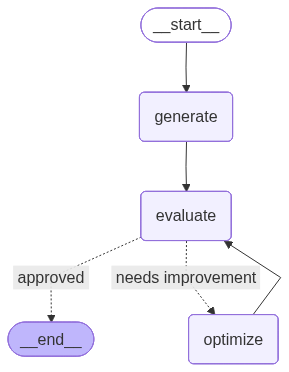

In [31]:
wf

In [36]:
input = {
    'topic' : 'Cristiano Ronaldo'
}

out = wf.invoke(input)

(out)

{'topic': 'Cristiano Ronaldo',
 'tweet': '"Cristiano Ronaldo\'s hair has its own Instagram account and more followers than me"',
 'evaluation': 'approved',
 'feedback': "This tweet is a great example of a well-crafted joke. It has originality, as the concept of Cristiano Ronaldo's hair having its own Instagram account is a unique and humorous idea. The humor is also well-executed, as the comparison between the hair's followers and the speaker's followers is a clever and relatable punchline. The tweet is punchy, short, and scroll-stopping, making it likely to grab the reader's attention. The virality potential is high, as people will likely retweet and share this funny observation. The format is also well-done, as it's a single sentence that's under 280 characters and doesn't follow a traditional setup-punchline structure. Overall, this tweet is a great example of a well-written joke that effectively uses humor and originality to engage the reader."}